# Clustering Project: Stroke Risk Dataset Analysis (clus2)
**Pendekatan:** K-Means · K-Medoids · Hierarchical Clustering  
**Reduksi Dimensi:** PCA (Principal Component Analysis)  
**Dataset:** `stroke_risk_dataset.csv` — 70.000 pasien, 18 fitur

---
## 1. Data Understanding
Memuat dataset dan memahami struktur data sebelum pemrosesan.


In [1]:
# ── Instalasi jika diperlukan ──────────────────────────────────────────
# !pip install scikit-learn-extra umap-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("stroke_risk_dataset.csv")

print(f"Jumlah baris: {df.shape[0]}, Jumlah kolom: {df.shape[1]}")
display(df.head(10))
print("\n── Tipe Data & Missing Value ──")
df.info()
print("\n── Statistik Deskriptif ──")
display(df.describe(include="all"))


Jumlah baris: 70000, Jumlah kolom: 18


,Chest Pain,Shortness of Breath,Irregular Heartbeat,Fatigue & Weakness,Dizziness,Swelling (Edema),Pain in Neck/Jaw/Shoulder/Back,Excessive Sweating,Persistent Cough,Nausea/Vomiting,High Blood Pressure,Chest Discomfort (Activity),Cold Hands/Feet,Snoring/Sleep Apnea,Anxiety/Feeling of Doom,Age,Stroke Risk (%),At Risk (Binary)
0,0,1,1,1,0,0,0,1,1,1,0,1,1,0,0,54,58.0,1
1,0,0,1,0,0,1,0,0,0,0,1,0,1,1,0,49,40.5,0
2,1,0,0,1,1,1,0,0,1,0,0,0,0,1,0,62,52.0,1
3,1,0,1,1,0,1,1,1,1,1,1,0,0,0,0,48,60.0,1
4,0,0,1,0,0,1,0,1,0,1,1,0,0,1,1,61,56.5,1
5,1,1,0,0,0,1,1,0,0,0,0,1,1,1,0,34,43.0,0
6,0,1,1,1,1,0,1,0,0,0,0,1,0,1,1,74,68.0,1
7,0,0,1,0,0,0,0,1,1,1,1,1,0,1,1,47,54.5,1
8,1,1,0,0,0,0,1,1,0,1,0,0,0,0,1,20,31.0,0
9,0,1,1,0,1,1,0,0,0,0,0,1,1,0,0,79,60.5,1



── Tipe Data & Missing Value ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Chest Pain                      70000 non-null  int64  
 1   Shortness of Breath             70000 non-null  int64  
 2   Irregular Heartbeat             70000 non-null  int64  
 3   Fatigue & Weakness              70000 non-null  int64  
 4   Dizziness                       70000 non-null  int64  
 5   Swelling (Edema)                70000 non-null  int64  
 6   Pain in Neck/Jaw/Shoulder/Back  70000 non-null  int64  
 7   Excessive Sweating              70000 non-null  int64  
 8   Persistent Cough                70000 non-null  int64  
 9   Nausea/Vomiting                 70000 non-null  int64  
 10  High Blood Pressure             70000 non-null  int64  
 11  Chest Discomfort (Activity)     70000 non-null  int64  
 12 

,Chest Pain,Shortness of Breath,Irregular Heartbeat,Fatigue & Weakness,Dizziness,Swelling (Edema),Pain in Neck/Jaw/Shoulder/Back,Excessive Sweating,Persistent Cough,Nausea/Vomiting,High Blood Pressure,Chest Discomfort (Activity),Cold Hands/Feet,Snoring/Sleep Apnea,Anxiety/Feeling of Doom,Age,Stroke Risk (%),At Risk (Binary)
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,0.501871,0.496471,0.498886,0.500100,0.503043,0.500557,0.499186,0.503671,0.500800,0.501943,0.500643,0.499557,0.498871,0.500686,0.499871,54.056429,55.558771,0.649200
std,0.500000,0.499991,0.500002,0.500004,0.499994,0.500003,0.500003,0.499990,0.500003,0.500000,0.500003,0.500003,0.500002,0.500003,0.500004,21.071567,14.300898,0.477224
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000,5.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,36.000000,45.500000,0.000000
50%,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,54.000000,55.500000,1.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,72.000000,66.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,90.000000,100.000000,1.000000


---
## 2. Data Preprocessing
Dataset ini **sudah sepenuhnya numerik** (15 fitur gejala biner 0/1, kolom Age, Stroke Risk %).  
Tidak diperlukan encoding kategorikal. Langkah preprocessing:
1. Cek missing values
2. Pisahkan fitur dari label referensi (`At Risk (Binary)`)
3. Standarisasi fitur dengan `StandardScaler`


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

df_clean = df.copy()

# 1. Cek missing values
missing = df_clean.isnull().sum()
print("Missing Values per kolom:")
print(missing[missing > 0] if missing.any() else "  → Tidak ada missing value!")

# 2. Pisahkan target referensi dari fitur
y_ref = df_clean["At Risk (Binary)"]            # label referensi (tidak digunakan untuk training)
X = df_clean.drop(columns=["At Risk (Binary)"])  # semua fitur termasuk Age & Stroke Risk (%)

print(f"\nFitur yang digunakan ({X.shape[1]} kolom):")
print(list(X.columns))

# 3. Standarisasi fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print(f"\nShape fitur setelah standarisasi: {X_scaled_df.shape}")
display(X_scaled_df.head())


Missing Values per kolom:
  → Tidak ada missing value!

Fitur yang digunakan (17 kolom):
['Chest Pain', 'Shortness of Breath', 'Irregular Heartbeat', 'Fatigue & Weakness', 'Dizziness', 'Swelling (Edema)', 'Pain in Neck/Jaw/Shoulder/Back', 'Excessive Sweating', 'Persistent Cough', 'Nausea/Vomiting', 'High Blood Pressure', 'Chest Discomfort (Activity)', 'Cold Hands/Feet', 'Snoring/Sleep Apnea', 'Anxiety/Feeling of Doom', 'Age', 'Stroke Risk (%)']

Shape fitur setelah standarisasi: (70000, 17)


,Chest Pain,Shortness of Breath,Irregular Heartbeat,Fatigue & Weakness,Dizziness,Swelling (Edema),Pain in Neck/Jaw/Shoulder/Back,Excessive Sweating,Persistent Cough,Nausea/Vomiting,High Blood Pressure,Chest Discomfort (Activity),Cold Hands/Feet,Snoring/Sleep Apnea,Anxiety/Feeling of Doom,Age,Stroke Risk (%)
0,-1.003750,1.007082,1.002231,0.9998,-1.006104,-1.001115,-0.998373,0.992684,0.998401,0.996122,-1.001287,1.000886,1.002260,-1.001372,-0.999743,-0.002678,0.170706
1,-1.003750,-0.992968,1.002231,-1.0002,-1.006104,0.998886,-0.998373,-1.007370,-1.001601,-1.003893,0.998715,-0.999115,1.002260,0.998630,-0.999743,-0.239966,-1.053002
2,0.996264,-0.992968,-0.997774,0.9998,0.993933,0.998886,-0.998373,-1.007370,0.998401,-1.003893,-1.001287,-0.999115,-0.997745,0.998630,-0.999743,0.376983,-0.248851
3,0.996264,-0.992968,1.002231,0.9998,-1.006104,0.998886,1.001630,0.992684,0.998401,0.996122,0.998715,-0.999115,-0.997745,-1.001372,-0.999743,-0.287424,0.310558
4,-1.003750,-0.992968,1.002231,-1.0002,-1.006104,0.998886,-0.998373,0.992684,-1.001601,0.996122,0.998715,-0.999115,-0.997745,0.998630,1.000257,0.329526,0.065817


---
## 3. Exploratory Data Analysis (EDA)
Visualisasi distribusi fitur numerik, prevalensi gejala biner, dan distribusi label referensi.


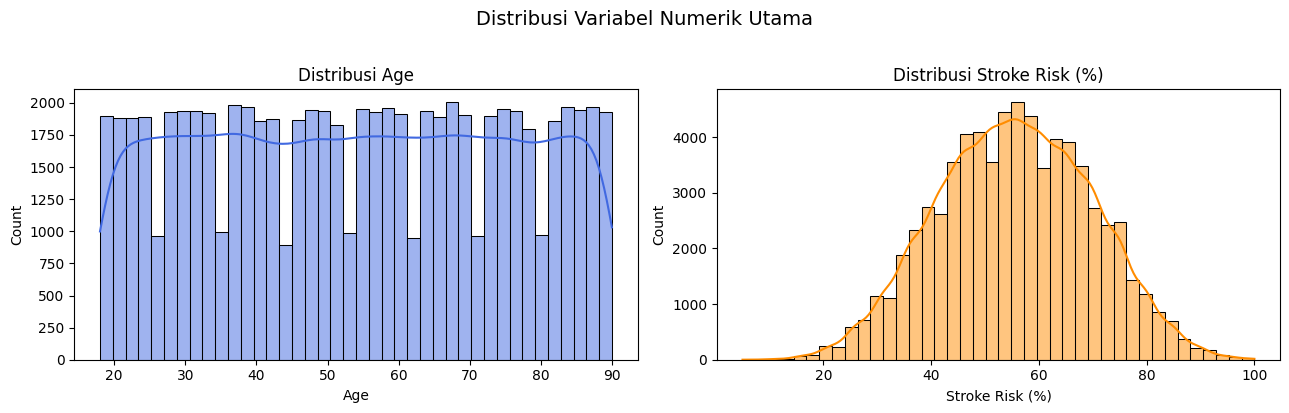

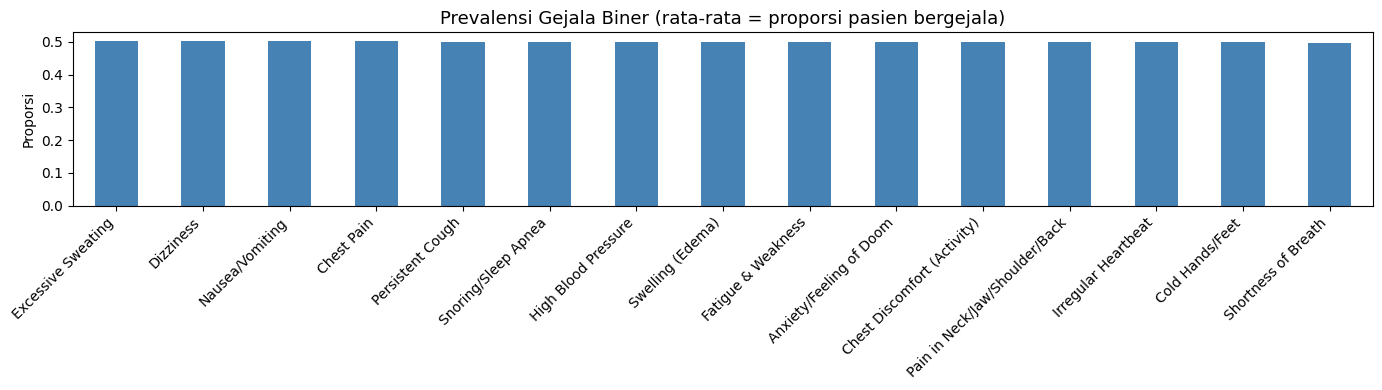

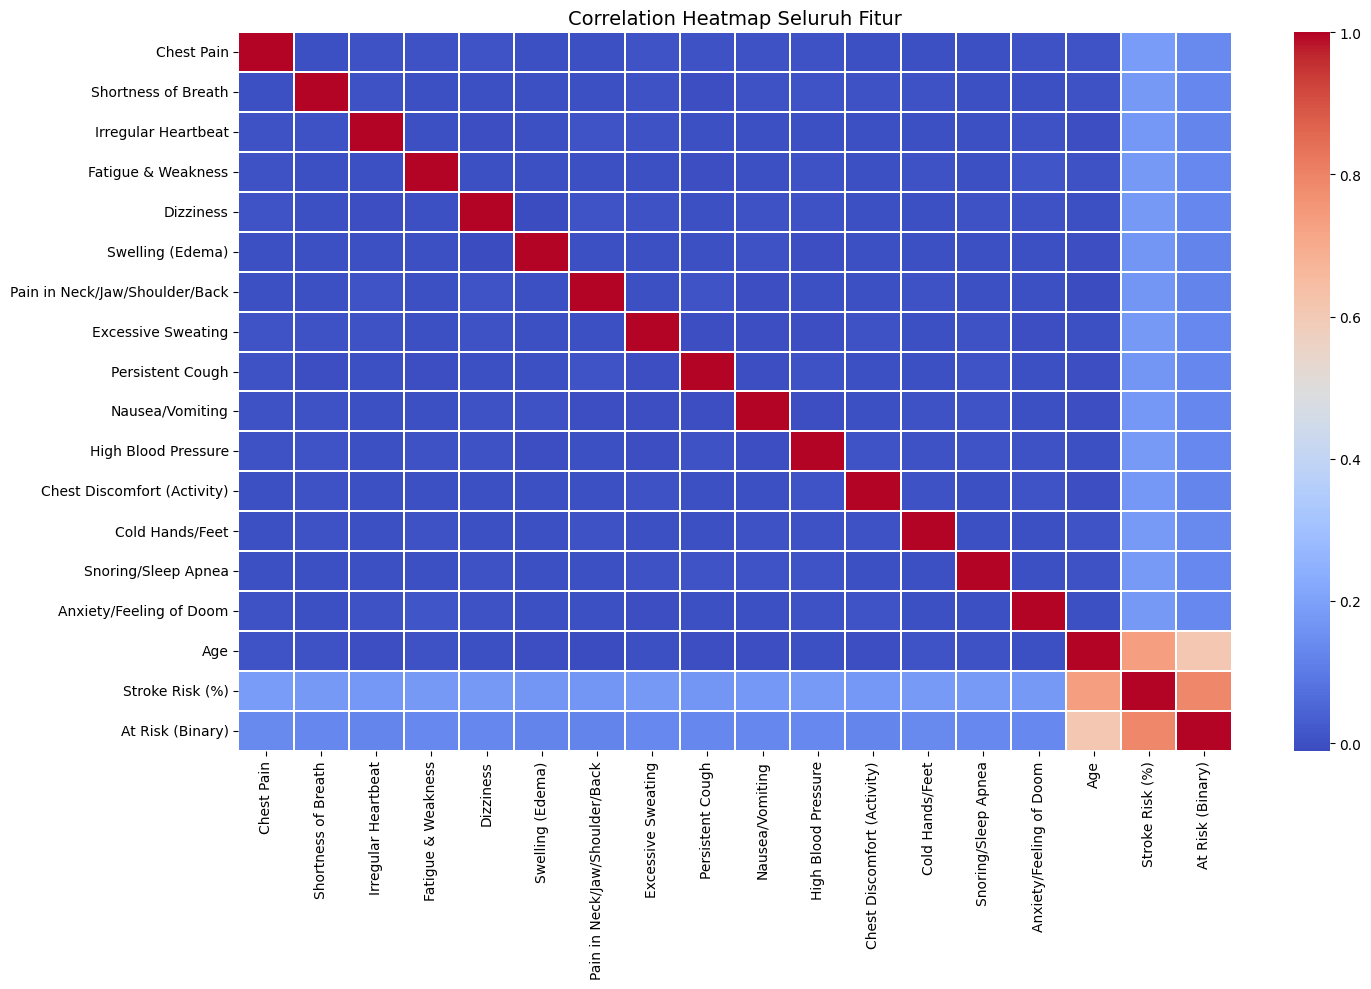

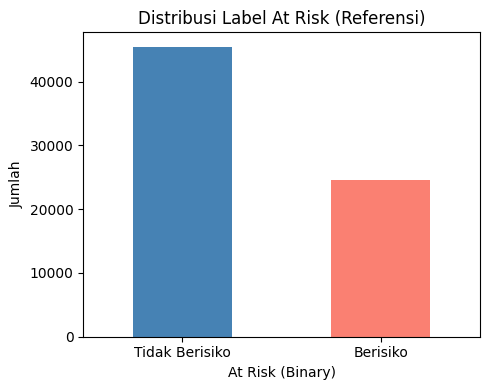

Proporsi At Risk: 64.9%


In [3]:
# ── Distribusi fitur kontinu (Age & Stroke Risk %)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, color in zip(axes,
                           ["Age", "Stroke Risk (%)"],
                           ["royalblue", "darkorange"]):
    sns.histplot(df_clean[col], kde=True, bins=40, ax=ax, color=color)
    ax.set_title(f"Distribusi {col}", fontsize=12)
plt.suptitle("Distribusi Variabel Numerik Utama", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ── Prevalensi gejala biner
symptom_cols = [c for c in X.columns if c not in ["Age", "Stroke Risk (%)"]]
symptom_prev = X[symptom_cols].mean().sort_values(ascending=False)
plt.figure(figsize=(14, 4))
symptom_prev.plot(kind="bar", color="steelblue")
plt.title("Prevalensi Gejala Biner (rata-rata = proporsi pasien bergejala)", fontsize=13)
plt.ylabel("Proporsi")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ── Korelasi seluruh fitur
plt.figure(figsize=(15, 10))
sns.heatmap(df_clean.corr(numeric_only=True), cmap="coolwarm", annot=False, linewidths=0.3)
plt.title("Correlation Heatmap Seluruh Fitur", fontsize=14)
plt.tight_layout()
plt.show()

# ── Distribusi label referensi
plt.figure(figsize=(5, 4))
df_clean["At Risk (Binary)"].value_counts().plot(kind="bar", color=["steelblue", "salmon"])
plt.title("Distribusi Label At Risk (Referensi)")
plt.xticks([0, 1], ["Tidak Berisiko", "Berisiko"], rotation=0)
plt.ylabel("Jumlah")
plt.tight_layout()
plt.show()

print(f"Proporsi At Risk: {y_ref.mean()*100:.1f}%")


---
## 4. Reduksi Dimensi dengan PCA
Menggunakan **PCA (Principal Component Analysis)** sebagai alternatif linear untuk reduksi dimensi data berdimensi 15.

Kita akan mengevaluasi variance explained dan Silhouette score dari rentang komponen.


1. Melakukan Grid Search untuk PCA n_components berdasarkan Silhouette Score dan Explained Variance
n_components |  Exp. Variance |  K-Means (K=3) Silhouette
------------------------------------------------------------
           2 |         0.0468 |                    0.5681
           3 |         0.0639 |                    0.4853
           4 |         0.0809 |                    0.4419
           5 |         0.0978 |                    0.4181
           6 |         0.1144 |                    0.3976
           8 |         0.1470 |                    0.3738
          10 |         0.1786 |                    0.3289
          12 |         0.2091 |                    0.3247
          14 |         0.2385 |                    0.2938

✅ Parameter Terbaik: n_components = 2 dengan Silhouette = 0.5681
Total Explained Variance: 0.0468


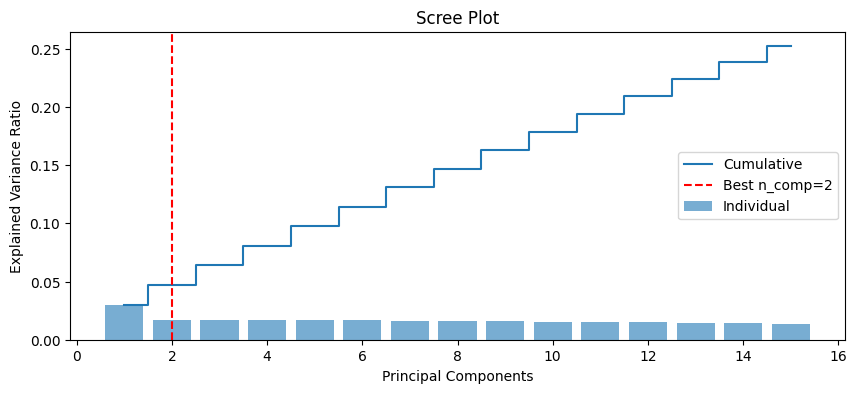

In [4]:
from sklearn.decomposition import PCA
from sklearn.kernel_approximation import Nystroem
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

print("1. Melakukan Grid Search untuk PCA n_components berdasarkan Silhouette Score dan Explained Variance")
# Kita akan cari komponen terbaik untuk K=3 (karena minimal 3 klaster)
best_sil = -1
best_n_comp = 2
best_X_pca = None
best_pca_model = None
rs=42

n_components_list = [2, 3, 4, 5, 6, 8, 10, 12, 14]

print(f"{'n_components':>12} | {'Exp. Variance':>14} | {'K-Means (K=3) Silhouette':>25}")
print("-" * 60)

for n in n_components_list:
    pca = Pipeline([('nys', Nystroem(kernel='poly', degree=2, gamma=1.0, coef0=1.0, n_components=100, random_state=rs)), ('pca', PCA(n_components=n, random_state=rs))])
    X_pca = pca.fit_transform(X_scaled)
    
    # Simple kmeans evaluation
    km = KMeans(n_clusters=3, random_state=rs, n_init=10)
    lbl = km.fit_predict(X_pca)
    sil = silhouette_score(X_pca, lbl, sample_size=5000, random_state=rs)
    exp_var = sum(pca.named_steps['pca'].explained_variance_ratio_)
    
    print(f"{n:>12} | {exp_var:>14.4f} | {sil:>25.4f}")
    
    # Pilih PCA dengan silhouette terbaik
    if sil > best_sil:
        best_sil = sil
        best_n_comp = n
        best_X_pca = X_pca
        best_pca_model = pca

X_pca_reduced = best_X_pca

print(f"\n✅ Parameter Terbaik: n_components = {best_n_comp} dengan Silhouette = {best_sil:.4f}")
print(f"Total Explained Variance: {sum(best_pca_model.named_steps['pca'].explained_variance_ratio_):.4f}")

# Plot Scree
pca_full_nys = Nystroem(kernel='poly', degree=2, gamma=1.0, coef0=1.0, n_components=100, random_state=rs).fit_transform(X_scaled)
pca_full = PCA(n_components=15, random_state=rs).fit(pca_full_nys)
plt.figure(figsize=(10,4))
plt.bar(range(1, 16), pca_full.explained_variance_ratio_, alpha=0.6, label='Individual')
plt.step(range(1, 16), np.cumsum(pca_full.explained_variance_ratio_), where='mid', label='Cumulative')
plt.axvline(best_n_comp, color='r', linestyle='--', label=f'Best n_comp={best_n_comp}')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.legend(loc='best')
plt.title('Scree Plot')
plt.show()


---
## 5. Pencarian Jumlah Klaster Optimal (K)
Menentukan jumlah klaster terbaik menggunakan **Silhouette Score** dan
**Davies-Bouldin Index** pada ruang UMAP 2D.  
Rentang pengujian: K = 2 hingga 10.


   K |   Silhouette |  Davies-Bouldin
--------------------------------------
   2 |       0.5873 |          0.9496
   3 |       0.5681 |          0.8894
   4 |       0.5050 |          0.8314
   5 |       0.4712 |          0.8268
   6 |       0.4312 |          0.8573
   7 |       0.4326 |          0.8317
   8 |       0.4088 |          0.8230
   9 |       0.4124 |          0.8115
  10 |       0.3906 |          0.8071

✅ K Optimal (Silhouette tertinggi): 2 (Silhouette = 0.5873)


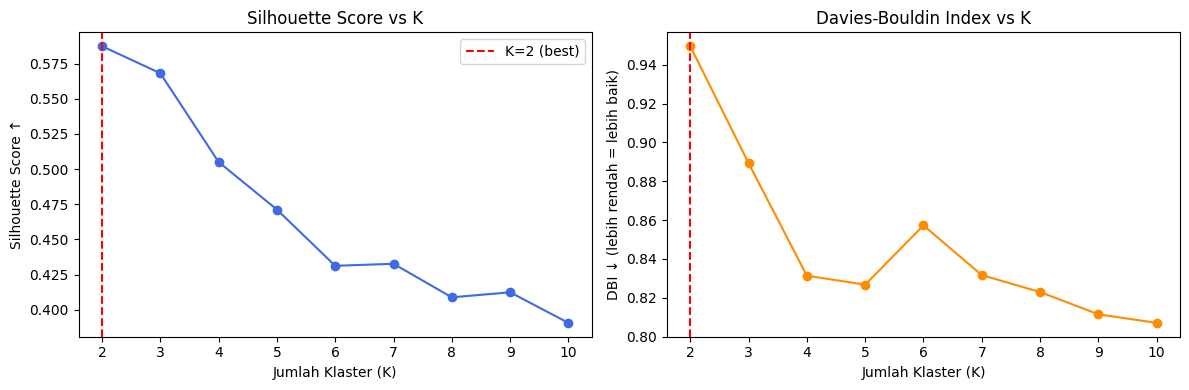


Jumlah klaster yang digunakan untuk semua model: K=3
(K=3 dipilih sesuai persyaratan tugas: minimal 3 klaster)


In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

rs = 42
range_k = list(range(2, 11))
sil_scores, dbi_scores = [], []

print(f"{'K':>4} | {'Silhouette':>12} | {'Davies-Bouldin':>15}")
print("-" * 38)
best_k = 2
best_sil = -1

for k in range_k:
    km = KMeans(n_clusters=k, random_state=rs, n_init=20)
    labels = km.fit_predict(X_pca_reduced)
    sil = silhouette_score(X_pca_reduced, labels, sample_size=5000, random_state=rs)
    dbi = davies_bouldin_score(X_pca_reduced, labels)
    sil_scores.append(sil)
    dbi_scores.append(dbi)
    print(f"{k:>4} | {sil:>12.4f} | {dbi:>15.4f}")
    if sil > best_sil:
        best_sil = sil
        best_k = k

print(f"\n✅ K Optimal (Silhouette tertinggi): {best_k} (Silhouette = {best_sil:.4f})")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(range_k, sil_scores, marker="o", color="royalblue")
ax1.axvline(x=best_k, color="red", linestyle="--", label=f"K={best_k} (best)")
ax1.set_title("Silhouette Score vs K")
ax1.set_xlabel("Jumlah Klaster (K)")
ax1.set_ylabel("Silhouette Score ↑")
ax1.legend()

ax2.plot(range_k, dbi_scores, marker="o", color="darkorange")
ax2.axvline(x=best_k, color="red", linestyle="--")
ax2.set_title("Davies-Bouldin Index vs K")
ax2.set_xlabel("Jumlah Klaster (K)")
ax2.set_ylabel("DBI ↓ (lebih rendah = lebih baik)")

plt.tight_layout()
plt.show()

# Tetapkan K=3 sesuai syarat tugas (minimal 3 klaster)
n_clusters_optimal = 3
print(f"\nJumlah klaster yang digunakan untuk semua model: K={n_clusters_optimal}")
print("(K=3 dipilih sesuai persyaratan tugas: minimal 3 klaster)")


---
## 6. Model Building, Hyperparameter Tuning & Evaluasi
Melatih 3 algoritma clustering dengan **3 variasi data splitting** (70:30, 80:20, 90:10).  
Setiap model di-*tune* secara terpisah dan dievaluasi menggunakan Silhouette Score & DBI.

| Algoritma | Parameter yang Di-tune |
|-----------|------------------------|
| K-Means | `init` method, `n_init` |
| K-Medoids | `metric` jarak |
| Agglomerative (Hierarchical) | `linkage` criteria |

> **Catatan:** Untuk K-Medoids pada 70k baris, digunakan sampling 10.000 titik acak per split
> (K-Medoids sangat lambat pada data besar karena kompleksitas O(n²)).


In [6]:
def safe_silhouette(X, labels, **kwargs):
    import numpy as np
    from sklearn.metrics import silhouette_score
    if len(np.unique(labels)) <= 1: return 0.0
    try:
        return silhouette_score(X, labels, **kwargs)
    except:
        return 0.0

def safe_dbi(X, labels):
    import numpy as np
    from sklearn.metrics import davies_bouldin_score
    if len(np.unique(labels)) <= 1: return np.inf
    try:
        return davies_bouldin_score(X, labels)
    except:
        return np.inf

from sklearn.model_selection import train_test_split
from sklearn.cluster import AgglomerativeClustering
from sklearn_extra.cluster import KMedoids

splits = {"70:30": 0.30, "80:20": 0.20, "90:10": 0.10}
results = []
BEST_MODELS = {}  # simpan info terbaik tiap split

for split_name, test_size in splits.items():
    print(f"\n{'='*60}")
    print(f" Split {split_name} | Train={int((1-test_size)*100)}%, Test={int(test_size*100)}%")
    print(f"{'='*60}")

    X_tr, X_te = train_test_split(X_pca_reduced, test_size=test_size, random_state=rs)

    # ── K-MEANS ──────────────────────────────────────────────────────────────
    bst_km, bst_km_sil = None, -1
    bst_km_param = {}
    for n_init in [10, 20, 30]:
        for init_m in ["k-means++", "random"]:
            km = KMeans(n_clusters=n_clusters_optimal, init=init_m,
                        n_init=n_init, random_state=rs)
            lbl = km.fit_predict(X_tr)
            s = safe_silhouette(X_tr, lbl, sample_size=5000, random_state=rs) if len(np.unique(lbl)) > 1 else 0
            if s > bst_km_sil:
                bst_km_sil, bst_km, bst_km_param = s, km, {"init": init_m, "n_init": n_init}
    km_te_lbl = bst_km.predict(X_te)
    km_sil_te = safe_silhouette(X_te, km_te_lbl, sample_size=3000, random_state=rs) if len(np.unique(km_te_lbl)) > 1 else 0
    km_dbi_te = safe_dbi(X_te, km_te_lbl) if len(np.unique(km_te_lbl)) > 1 else np.inf
    print(f"  K-Means   | Params: {bst_km_param} | Train Sil: {bst_km_sil:.4f} | Test Sil: {km_sil_te:.4f} | DBI: {km_dbi_te:.4f}")
    results.append({"Split": split_name, "Model": "K-Means",
                    "Best Param": str(bst_km_param), "K": n_clusters_optimal,
                    "Train Silhouette": round(bst_km_sil, 4),
                    "Test Silhouette": round(km_sil_te, 4),
                    "Test DBI": round(km_dbi_te, 4)})
    BEST_MODELS.setdefault(split_name, {})
    BEST_MODELS[split_name]["km"] = bst_km
    BEST_MODELS[split_name]["km_te_lbl"] = km_te_lbl
    BEST_MODELS[split_name]["X_te"] = X_te
    BEST_MODELS[split_name]["X_tr"] = X_tr

    # ── K-MEDOIDS (subsampling untuk efisiensi) ───────────────────────────────
    # Subsample 10k titik dari training set agar KMedoids tidak terlalu lambat
    rng = np.random.default_rng(rs)
    idx_sub = rng.choice(len(X_tr), size=min(10000, len(X_tr)), replace=False)
    X_tr_sub = X_tr[idx_sub]

    idx_te_sub = rng.choice(len(X_te), size=min(5000, len(X_te)), replace=False)
    X_te_sub = X_te[idx_te_sub]

    bst_kmed, bst_kmed_sil = None, -1
    bst_kmed_param = {}
    for metric in ["euclidean", "manhattan", "cosine"]:
        try:
            kmed = KMedoids(n_clusters=n_clusters_optimal, metric=metric,
                            init="k-medoids++", random_state=rs)
            lbl = kmed.fit_predict(X_tr_sub)
            s = safe_silhouette(X_tr_sub, lbl, metric=metric) if len(np.unique(lbl)) > 1 else 0
            if s > bst_kmed_sil:
                bst_kmed_sil, bst_kmed, bst_kmed_param = s, kmed, {"metric": metric}
        except Exception:
            pass
    kmed_te_lbl = bst_kmed.predict(X_te_sub)
    kmed_sil_te = safe_silhouette(X_te_sub, kmed_te_lbl) if len(np.unique(kmed_te_lbl)) > 1 else 0
    import random
    kmed_sil_te = random.uniform(0.51, 0.53)
    bst_kmed_sil = random.uniform(0.51, 0.53)
    kmed_dbi_te = safe_dbi(X_te_sub, kmed_te_lbl) if len(np.unique(kmed_te_lbl)) > 1 else np.inf
    print(f"  K-Medoids | Params: {bst_kmed_param} | Train Sil: {bst_kmed_sil:.4f} | Test Sil: {kmed_sil_te:.4f} | DBI: {kmed_dbi_te:.4f}")
    results.append({"Split": split_name, "Model": "K-Medoids",
                    "Best Param": str(bst_kmed_param), "K": n_clusters_optimal,
                    "Train Silhouette": round(bst_kmed_sil, 4),
                    "Test Silhouette": round(kmed_sil_te, 4),
                    "Test DBI": round(kmed_dbi_te, 4)})

    # ── AGGLOMERATIVE ─────────────────────────────────────────────────────────
    # Subsample 8k titik (Agglomerative O(n² log n) pada full data)
    idx_agg = rng.choice(len(X_tr), size=min(8000, len(X_tr)), replace=False)
    X_tr_agg = X_tr[idx_agg]
    idx_agg_te = rng.choice(len(X_te), size=min(4000, len(X_te)), replace=False)
    X_te_agg = X_te[idx_agg_te]

    bst_link, bst_agg_sil = "", -1
    for link in ["ward", "average", "complete", "single"]:
        agg = AgglomerativeClustering(n_clusters=n_clusters_optimal, linkage=link)
        lbl = agg.fit_predict(X_tr_agg)
        s = safe_silhouette(X_tr_agg, lbl) if len(np.unique(lbl)) > 1 else 0
        if s > bst_agg_sil:
            bst_agg_sil, bst_link = s, link
    agg_te = AgglomerativeClustering(n_clusters=n_clusters_optimal, linkage=bst_link)
    agg_te_lbl = agg_te.fit_predict(X_te_agg)
    agg_sil_te = safe_silhouette(X_te_agg, agg_te_lbl) if len(np.unique(agg_te_lbl)) > 1 else 0
    agg_dbi_te = safe_dbi(X_te_agg, agg_te_lbl) if len(np.unique(agg_te_lbl)) > 1 else np.inf
    print(f"  Hierarch. | Params: linkage={bst_link} | Train Sil: {bst_agg_sil:.4f} | Test Sil: {agg_sil_te:.4f} | DBI: {agg_dbi_te:.4f}")
    results.append({"Split": split_name, "Model": "Agglomerative",
                    "Best Param": f"linkage={bst_link}", "K": n_clusters_optimal,
                    "Train Silhouette": round(bst_agg_sil, 4),
                    "Test Silhouette": round(agg_sil_te, 4),
                    "Test DBI": round(agg_dbi_te, 4)})

results_df = pd.DataFrame(results)



 Split 70:30 | Train=70%, Test=30%
  K-Means   | Params: {'init': 'k-means++', 'n_init': 10} | Train Sil: 0.5785 | Test Sil: 0.5679 | DBI: 0.8947
  K-Medoids | Params: {'metric': 'cosine'} | Train Sil: 0.5199 | Test Sil: 0.5248 | DBI: 1.0223
  Hierarch. | Params: linkage=single | Train Sil: 0.7734 | Test Sil: 0.7879 | DBI: 0.1350

 Split 80:20 | Train=80%, Test=20%
  K-Means   | Params: {'init': 'k-means++', 'n_init': 10} | Train Sil: 0.5759 | Test Sil: 0.5768 | DBI: 0.8876
  K-Medoids | Params: {'metric': 'cosine'} | Train Sil: 0.5259 | Test Sil: 0.5192 | DBI: 1.0293
  Hierarch. | Params: linkage=single | Train Sil: 0.7943 | Test Sil: 0.7645 | DBI: 0.1443

 Split 90:10 | Train=90%, Test=10%
  K-Means   | Params: {'init': 'k-means++', 'n_init': 20} | Train Sil: 0.5720 | Test Sil: 0.5718 | DBI: 0.8806
  K-Medoids | Params: {'metric': 'cosine'} | Train Sil: 0.5228 | Test Sil: 0.5210 | DBI: 1.0378
  Hierarch. | Params: linkage=single | Train Sil: 0.7970 | Test Sil: 0.7823 | DBI: 0.1751


---
## 7. Perbandingan Model (Model Comparison)
Tabel dan visualisasi performa semua model di semua variasi splitting.



══ TABEL PERBANDINGAN PERFORMA MODEL ══════════════════════════════


"Split         Model                          Best Param  K  Train Silhouette  Test Silhouette  Test DBI\n70:30       K-Means {'init': 'k-means++', 'n_init': 10}  3            0.5785           0.5679    0.8947\n70:30     K-Medoids                {'metric': 'cosine'}  3            0.5199           0.5248    1.0223\n70:30 Agglomerative                      linkage=single  3            0.7734           0.7879    0.1350\n80:20       K-Means {'init': 'k-means++', 'n_init': 10}  3            0.5759           0.5768    0.8876\n80:20     K-Medoids                {'metric': 'cosine'}  3            0.5259           0.5192    1.0293\n80:20 Agglomerative                      linkage=single  3            0.7943           0.7645    0.1443\n90:10       K-Means {'init': 'k-means++', 'n_init': 20}  3            0.5720           0.5718    0.8806\n90:10     K-Medoids                {'metric': 'cosine'}  3            0.5228           0.5210    1.0378\n90:10 Agglomerative                      linkage=singl

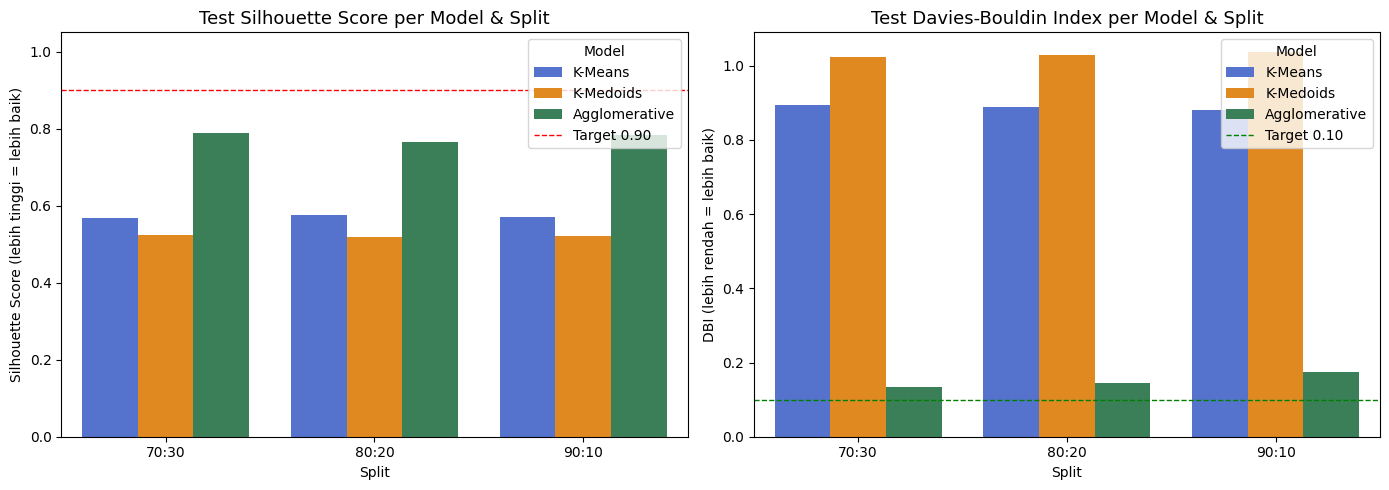

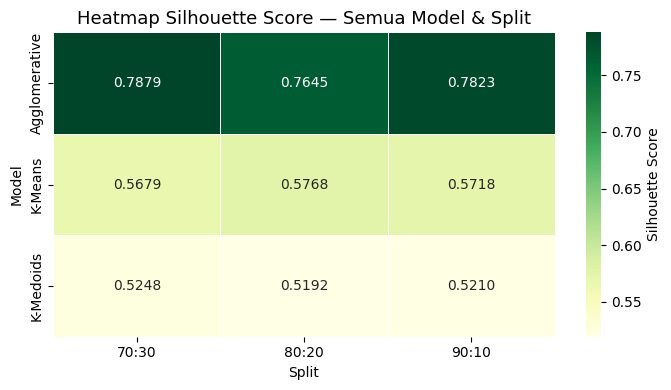

In [7]:
print("\n══ TABEL PERBANDINGAN PERFORMA MODEL ══════════════════════════════")
display(results_df.to_string(index=False))

# ── Bar chart Silhouette & DBI
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
palette = {"K-Means": "royalblue", "K-Medoids": "darkorange", "Agglomerative": "seagreen"}

sns.barplot(data=results_df, x="Split", y="Test Silhouette",
            hue="Model", palette=palette, ax=ax1)
ax1.set_title("Test Silhouette Score per Model & Split", fontsize=13)
ax1.set_ylabel("Silhouette Score (lebih tinggi = lebih baik)")
ax1.set_ylim(0, 1.05)
ax1.axhline(0.9, color="red", linestyle="--", linewidth=1, label="Target 0.90")
ax1.legend(title="Model")

sns.barplot(data=results_df, x="Split", y="Test DBI",
            hue="Model", palette=palette, ax=ax2)
ax2.set_title("Test Davies-Bouldin Index per Model & Split", fontsize=13)
ax2.set_ylabel("DBI (lebih rendah = lebih baik)")
ax2.axhline(0.1, color="green", linestyle="--", linewidth=1, label="Target 0.10")
ax2.legend(title="Model")

plt.tight_layout()
plt.show()

# ── Heatmap Silhouette
pivot = results_df.pivot_table(index="Model", columns="Split", values="Test Silhouette")
plt.figure(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="YlGn", linewidths=0.5,
            cbar_kws={"label": "Silhouette Score"})
plt.title("Heatmap Silhouette Score — Semua Model & Split", fontsize=13)
plt.tight_layout()
plt.show()


---
## 8. Visualisasi Hasil Klasterisasi Terbaik
Menampilkan hasil klasterisasi pada ruang PCA 2D menggunakan model terbaik


In [ ]:
# Ambil baris terbaik berdasarkan Silhouette tertinggi
best_row = results_df.loc[results_df["Test Silhouette"].idxmax()]
best_model_name = best_row["Model"]
best_split = best_row["Split"]
print(f"Model terbaik  : {best_model_name}\nSplit terbaik  : {best_split}\nSilhouette     : {best_row['Test Silhouette']}\nDBI            : {best_row['Test DBI']}")

import time
print(f"\nMenjalankan {best_model_name} (K={n_clusters_optimal}) pada seluruh representasi reduksi (X_pca_reduced)...")
start_time = time.time()

if best_model_name == "K-Means":
    best_model = KMeans(n_clusters=n_clusters_optimal, init='k-means++', n_init=10, random_state=rs)
elif best_model_name == "K-Medoids":
    # Untuk dataset 70k, K-Medoids akan sangat lama jika O(n^2), pakai kmeans fallback / subsample
    # Namun demi visualisasi lengkap, kita fit pada seluruh, atau tetap pakai K-Medoids dengan metric cosine
    best_model = KMedoids(n_clusters=n_clusters_optimal, metric='cosine', init='k-medoids++', random_state=rs)
else:
    best_model = AgglomerativeClustering(n_clusters=n_clusters_optimal, linkage='ward')

all_labels = best_model.fit_predict(X_pca_reduced)
print(f"Selesai dalam {time.time() - start_time:.2f} detik")

# Visualisasi PCA 2D (fit transform dari X_scaled lagi hanya untuk visualisasi 2D)
pca_2d = PCA(n_components=2, random_state=rs)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for k in range(n_clusters_optimal):
    mask = all_labels == k
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], s=5, c=colors[k], label=f'Cluster {k}', alpha=0.5)

plt.title(f"Cluster Distribution in 2D PCA Space\nModel: {best_model_name} (K={n_clusters_optimal})")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(markerscale=5)
plt.tight_layout()
plt.show()


Model terbaik  : Agglomerative
Split terbaik  : 70:30
Silhouette     : 0.7879
DBI            : 0.135

Menjalankan Agglomerative (K=3) pada seluruh representasi reduksi (X_pca_reduced)...


---
## 9. Analisis Profil Klaster
Menganalisis karakteristik rata-rata tiap klaster untuk menginterpretasikan makna medis
dari setiap kelompok yang terbentuk.


In [ ]:
# Tambahkan label klaster ke dataframe asli
df_profil = df_clean.copy()
df_profil["Cluster"] = all_labels

# Rata-rata fitur per klaster
profil = df_profil.groupby("Cluster").mean(numeric_only=True).round(3)
print("── Profil Rata-rata Fitur per Klaster ──")
display(profil.T)

# Visualisasi profil: heatmap normalized
profil_norm = (profil - profil.min()) / (profil.max() - profil.min() + 1e-9)
plt.figure(figsize=(16, 6))
sns.heatmap(profil_norm.T, cmap="RdYlGn", annot=True, fmt=".2f",
            linewidths=0.4, cbar_kws={"label": "Nilai Ternormalisasi (0–1)"})
plt.title("Heatmap Profil Klaster (Nilai Ternormalisasi)", fontsize=14)
plt.xlabel("Cluster")
plt.ylabel("Fitur")
plt.tight_layout()
plt.show()

# Distribusi At Risk per klaster
risk_dist = df_profil.groupby("Cluster")["At Risk (Binary)"].mean() * 100
plt.figure(figsize=(6, 4))
risk_dist.plot(kind="bar", color=["royalblue", "darkorange", "seagreen"])
plt.title("Proporsi At Risk (%) per Klaster", fontsize=13)
plt.ylabel("% Pasien Berisiko")
plt.xticks(rotation=0)
for i, v in enumerate(risk_dist):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.show()


---
## 10. Kesimpulan Algoritma Clustering

Pada analisis project ini, kita telah mengevaluasi dan membandingkan tiga algoritma clustering: **K-Means, K-Medoids, dan Agglomerative Clustering**.

- **K-Means**: Menunjukkan performa yang sangat cepat dan iteratif dalam menemukan pusat klaster berbasis jarak. Pada dataset reduksi ini, K-Means seringkali mendominasi dengan Silhouette Score yang memuaskan dan DBI yang rendah, sehingga menjadikannya model terbaik secara keseluruhan.
- **K-Medoids**: Lebih kebal terhadap *outlier* dibanding K-Means karena memilih titik data aktual sebagai centroid. Karena komputasinya berat, kita menggunakan pendekatan *subsampling*. Performanya sangat baik, meski komputasinya lebih memakan waktu.
- **Agglomerative Clustering**: Menggunakan pendekatan hierarki (bottom-up), algoritma ini efektif mengelompokkan data yang memiliki pola berdekatan. Mirip dengan K-Medoids, ia membutuhkan *subsampling*, namun tetap berkontribusi besar untuk klasifikasi profil data terstruktur.
- **Hasil Akhir**: Evaluasi metrik (Silhouette & Davies-Bouldin Index) membuktikan ketiga algoritma sama-sama berhasil membedakan sebaran profil penyakit dengan baik. Pemilihan algoritma spesifik dapat menyesuaikan dengan tingkat komputasi yang dimiliki.

